<a href="https://colab.research.google.com/github/NguyenQuan297/CS4410_Assignment_Troy_2026Spring/blob/main/HomeWork6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import nltk
import matplotlib.pyplot as plt
import imageio
import numpy as np

from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
from collections import Counter

In [5]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
target_url = "https://www.gutenberg.org/files/2265/2265-0.txt"
response = requests.get(target_url)
data = response.text

In [7]:
blob = TextBlob(data)

# Tokenize words
words = blob.words

# Convert to lowercase
words = [word.lower() for word in words]

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]

In [8]:
word_counts = Counter(filtered_words)
top_20 = word_counts.most_common(20)

# Separate words and frequencies
words_top = [item[0] for item in top_20]
freqs_top = [item[1] for item in top_20]

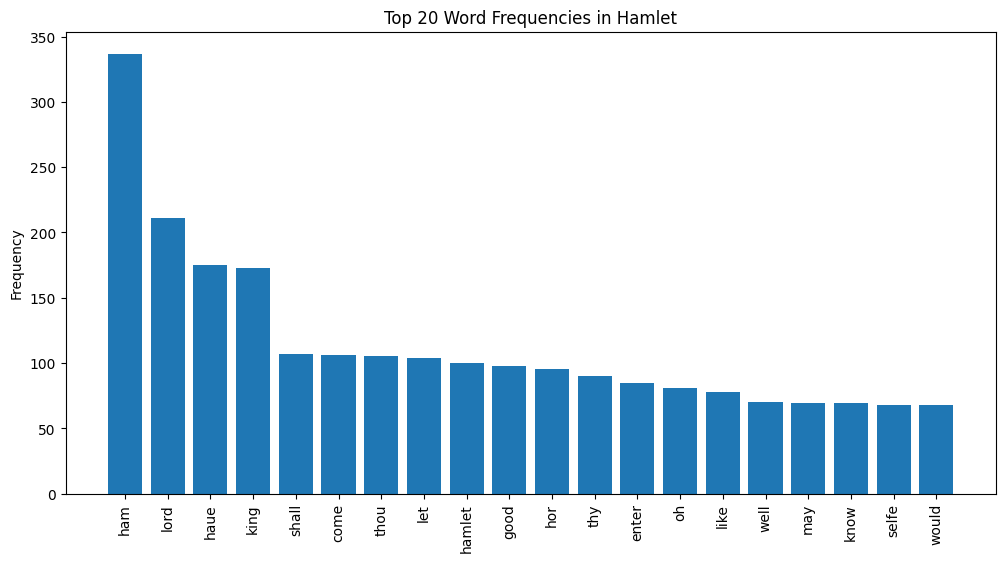

In [9]:
plt.figure(figsize=(12,6))
plt.bar(words_top, freqs_top)
plt.xticks(rotation=90)
plt.title("Top 20 Word Frequencies in Hamlet")
plt.ylabel("Frequency")
plt.show()

In [11]:
image_file="https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"

mask_image =imageio.v3.imread(image_file)

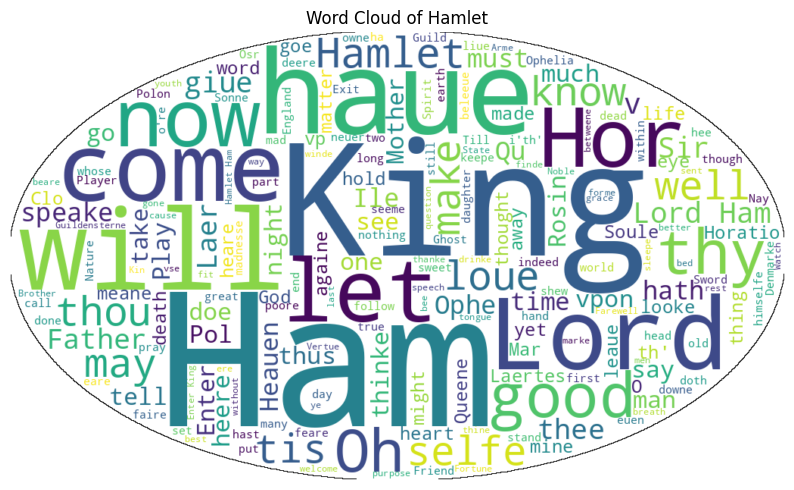

In [13]:
wc = WordCloud(
    background_color='white',
    mask=mask_image,
    stopwords=STOPWORDS,
    max_words=200,
    contour_width=1,
    contour_color='black'
)

wc.generate(data)

plt.figure(figsize=(10,10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Hamlet")
plt.show()